In [5]:
import pandas as pd

small_file = r"D:\CSE-CICIDS2018\Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv"
df_check = pd.read_csv(small_file, nrows=5)
df_check.columns = df_check.columns.str.strip()
print(f"Total columns: {len(df_check.columns)}")
print(df_check.columns.tolist())

# Check label column
print(f"\nLabel sample:")
df_label = pd.read_csv(small_file, nrows=200)
df_label.columns = df_label.columns.str.strip()
label_col = [c for c in df_label.columns if 'label' in c.lower()]
print(f"Label column name: {label_col}")
if label_col:
    print(df_label[label_col[0]].value_counts())

Total columns: 80
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk 

In [6]:
import pandas as pd

attack_file = r"D:\CSE-CICIDS2018\Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv"
df_labels = pd.read_csv(attack_file, usecols=lambda c: c.strip() == 'Label', low_memory=False)
df_labels.columns = df_labels.columns.str.strip()
print(df_labels['Label'].value_counts())

Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64


In [7]:
import pandas as pd
import os

path = r"D:\CSE-CICIDS2018"

for f in sorted(os.listdir(path)):
    fpath = os.path.join(path, f)
    df = pd.read_csv(fpath, usecols=lambda c: c.strip() == 'Label', low_memory=False)
    df.columns = df.columns.str.strip()
    print(f"\n{f}")
    print(df['Label'].value_counts())


Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
Label
Benign    762384
Bot       286191
Name: count, dtype: int64

Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
Label
DoS attacks-Hulk            461912
Benign                      446772
DoS attacks-SlowHTTPTest    139890
Label                            1
Name: count, dtype: int64

Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
Label
Benign              1048009
Brute Force -Web        362
Brute Force -XSS        151
SQL Injection            53
Name: count, dtype: int64

Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
Label
Benign                    7372557
DDoS attacks-LOIC-HTTP     576191
Name: count, dtype: int64

Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
Label
Benign           238037
Infilteration     93063
Label                25
Name: count, dtype: int64

Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
Label
Benign                   996077
DoS attacks-GoldenEye     41508
DoS attacks-Slowloris     10990
Name: count,

Cell 1 — Imports and Paths

In [8]:
import os, pickle, gc, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix,\
    ConfusionMatrixDisplay, precision_recall_curve, roc_auc_score
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import shap, matplotlib.pyplot as plt

DATA_PATH       = r'D:\CSE-CICIDS2018'
ARTIFACT_PATH   = r'..\artifacts'
CHECKPOINT_PATH = r'..\checkpoints'
os.makedirs(ARTIFACT_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# ── CHRONOLOGICAL SPLIT ─────────────────────────────────
TRAIN_FILES = [
    'Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv',  # FTP/SSH BruteForce
    'Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv',   # DoS GoldenEye/Slowloris
    'Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv',  # DDoS HOIC/LOIC-UDP
    'Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv',   # WebAttack
    'Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv',  # Infiltration
    'Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv',   # Infiltration cont.
]
TEST_FILES = [
    'Friday-16-02-2018_TrafficForML_CICFlowMeter.csv',     # DoS Hulk/SlowHTTP — UNSEEN
    'Friday-23-02-2018_TrafficForML_CICFlowMeter.csv',     # WebAttack diff instances
    'Friday-02-03-2018_TrafficForML_CICFlowMeter.csv',     # Botnet — UNSEEN
    'Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv',   # DDoS LOIC-HTTP — UNSEEN
]
ALL_FILES = TRAIN_FILES + TEST_FILES
BINARY_THRESHOLD = 0.85

Cell 2 — Feature List (CIC-IDS2018 column names)

In [9]:
FEATURES = [
    'Flow Duration',
    'Tot Fwd Pkts',
    'Tot Bwd Pkts',
    'TotLen Fwd Pkts',
    'TotLen Bwd Pkts',
    'Fwd Pkt Len Max',
    'Fwd Pkt Len Min',
    'Fwd Pkt Len Mean',
    'Bwd Pkt Len Max',
    'Bwd Pkt Len Min',
    'Bwd Pkt Len Mean',
    'Flow Byts/s',
    'Flow Pkts/s',
    'Flow IAT Mean',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd PSH Flags',
    'FIN Flag Cnt',
    'SYN Flag Cnt',
    'RST Flag Cnt',
    'PSH Flag Cnt',
    'ACK Flag Cnt',
    'Down/Up Ratio',
    'Fwd Seg Size Avg',
    'Bwd Seg Size Avg',
]

print(f"Feature count: {len(FEATURES)}")
print("Feature list locked.")

Feature count: 25
Feature list locked.


Cell 3 — Load and Clean (With Checkpoint + Tuesday chunking)

In [10]:
CHECKPOINT_FILE = os.path.join(CHECKPOINT_PATH, 'df_clean.pkl')
TUESDAY_FILE    = 'Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv'

if os.path.exists(CHECKPOINT_FILE):
    df = pd.read_pickle(CHECKPOINT_FILE)
    print(f'Checkpoint loaded: {df.shape}')
    if 'source_file' not in df.columns:
        print('WARNING: Old checkpoint lacks source_file — delete it and rerun.')
else:
    frames = []
    for fname in ALL_FILES:
        fpath = os.path.join(DATA_PATH, fname)
        if fname == TUESDAY_FILE:
            chunks = []
            for chunk in pd.read_csv(fpath,
                usecols=lambda c: c.strip() in FEATURES + ['Label'],
                low_memory=False, chunksize=500_000):
                chunk.columns = chunk.columns.str.strip()
                chunk = chunk[chunk['Label'] != 'Label']
                chunk['source_file'] = fname      # <-- TAG
                for col in chunk.select_dtypes(include='float64').columns:
                    chunk[col] = chunk[col].astype('float32')
                chunks.append(chunk)
            file_df = pd.concat(chunks, ignore_index=True)
            del chunks; gc.collect()
        else:
            file_df = pd.read_csv(fpath,
                usecols=lambda c: c.strip() in FEATURES + ['Label'],
                low_memory=False)
            file_df.columns = file_df.columns.str.strip()
            file_df = file_df[file_df['Label'] != 'Label']
            file_df['source_file'] = fname         # <-- TAG
            for col in file_df.select_dtypes(include='float64').columns:
                file_df[col] = file_df[col].astype('float32')
        frames.append(file_df)
        del file_df; gc.collect()

    df = pd.concat(frames, ignore_index=True)
    del frames; gc.collect()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    df.drop_duplicates(subset=FEATURES + ['Label'], inplace=True)   # de-dup on features only
    df.to_pickle(CHECKPOINT_FILE)
    print(f'Saved: {df.shape}')


Saved: (9777285, 27)


Cell 4 — Label Distribution

In [11]:
print("=== LABEL DISTRIBUTION ===\n")
counts = df['Label'].value_counts()
print(counts)
print(f"\nTotal rows: {len(df):,}")
benign = counts.get('Benign', 0)
attack = len(df) - benign
print(f"\nBenign: {benign:,} ({benign/len(df)*100:.1f}%)")
print(f"Attack: {attack:,} ({attack/len(df)*100:.1f}%)")

=== LABEL DISTRIBUTION ===

Label
Benign                      8487399
DDoS attacks-LOIC-HTTP       575256
DDOS attack-HOIC             198830
Bot                          143395
DoS attacks-Hulk             122294
Infilteration                102858
SSH-Bruteforce                93988
DoS attacks-GoldenEye         41356
DoS attacks-Slowloris          9239
DDOS attack-LOIC-UDP           1730
Brute Force -Web                527
Brute Force -XSS                225
SQL Injection                    80
DoS attacks-SlowHTTPTest         55
FTP-BruteForce                   53
Name: count, dtype: int64

Total rows: 9,777,285

Benign: 8,487,399 (86.8%)
Attack: 1,289,886 (13.2%)



Cell 5 — Encode + Split + Scale

In [12]:
CHECKPOINT_SPLIT = os.path.join(CHECKPOINT_PATH, 'split_chrono.pkl')

if os.path.exists(CHECKPOINT_SPLIT):
    with open(CHECKPOINT_SPLIT, 'rb') as f:
        X_train_scaled, X_test_scaled, y_train, y_test = pickle.load(f)
    print(f'Split loaded | Train={X_train_scaled.shape} Test={X_test_scaled.shape}')
else:
    df_train = df[df['source_file'].isin(TRAIN_FILES)].copy()
    df_test  = df[df['source_file'].isin(TEST_FILES)].copy()
    print(f'Train rows: {len(df_train):,} | Test rows: {len(df_test):,}')

    # Binary labels
    y_train = (df_train['Label'] != 'Benign').astype(int).values
    y_test  = (df_test['Label']  != 'Benign').astype(int).values

    X_train_raw = df_train[FEATURES].values.astype('float32')
    X_test_raw  = df_test[FEATURES].values.astype('float32')
    del df_train, df_test; gc.collect()

    # Fix inf
    for arr in [X_train_raw, X_test_raw]:
        col_means = np.nanmean(np.where(np.isinf(arr), np.nan, arr), axis=0)
        mask = np.isinf(arr)
        arr[mask] = np.take(col_means, np.where(mask)[1])

    # RobustScaler — fit on TRAIN only
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)
    del X_train_raw, X_test_raw; gc.collect()

    with open(os.path.join(ARTIFACT_PATH, 'scaler.pkl'), 'wb') as f:
        pickle.dump(scaler, f)
    print('scaler.pkl saved')

    # scale_pos_weight from TRAIN labels only
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    print(f'Train: {neg:,} benign | {pos:,} attack | spw={neg/pos:.2f}')

    print(f'Test: {(y_test==0).sum():,} benign | {(y_test==1).sum():,} attack')

    with open(CHECKPOINT_SPLIT, 'wb') as f:
        pickle.dump((X_train_scaled, X_test_scaled, y_train, y_test), f)
    print('Chronological split checkpoint saved')


Train rows: 3,132,600 | Test rows: 6,644,685
scaler.pkl saved
Train: 2,684,207 benign | 448,393 attack | spw=5.99
Test: 5,803,192 benign | 841,493 attack
Chronological split checkpoint saved


Cell 6 — Train XGBoost

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import time

# compute spw from the loaded y_train (chronological split)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight: {spw:.2f}')

CHECKPOINT_MODEL = os.path.join(ARTIFACT_PATH, 'model.pkl')
if os.path.exists(CHECKPOINT_MODEL):
    with open(CHECKPOINT_MODEL, 'rb') as f:
        model = pickle.load(f)
    print('model.pkl loaded')
else:
    model = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,    # from chronological train set
        min_child_weight=3,
        base_score=0.5,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
        cv=cv, scoring='f1', n_jobs=1)
    print(f'CV F1: {cv_scores.round(4)} | mean={cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    print(f'Trained in {time.time()-t0:.1f}s')
    with open(CHECKPOINT_MODEL, 'wb') as f: pickle.dump(model, f)
    print('model.pkl saved')


scale_pos_weight: 5.99
CV F1: [0.8054 0.8035 0.806  0.8094 0.8024] | mean=0.8054 ± 0.0024
Trained in 74.8s
model.pkl saved


Cell 7 — Evaluate

ROC-AUC: 0.8288

=== THRESHOLD SWEEP ===
Threshold    FPR%       FNR%       F1         Precision    Recall
0.50         3.75       49.53      0.5725     0.6614       0.5047
0.60         0.78       59.47      0.5557     0.8834       0.4053
0.70         0.42       60.32      0.5568     0.9325       0.3968
0.80         0.32       63.10      0.5305     0.9429       0.3690
0.85         0.30       65.59      0.5043     0.9436       0.3441
0.90         0.26       68.67      0.4708     0.9467       0.3133

=== REPORT AT THRESHOLD 0.85 ===
              precision    recall  f1-score   support

      Benign       0.91      1.00      0.95   5803192
      Attack       0.94      0.34      0.50    841493

    accuracy                           0.91   6644685
   macro avg       0.93      0.67      0.73   6644685
weighted avg       0.92      0.91      0.90   6644685



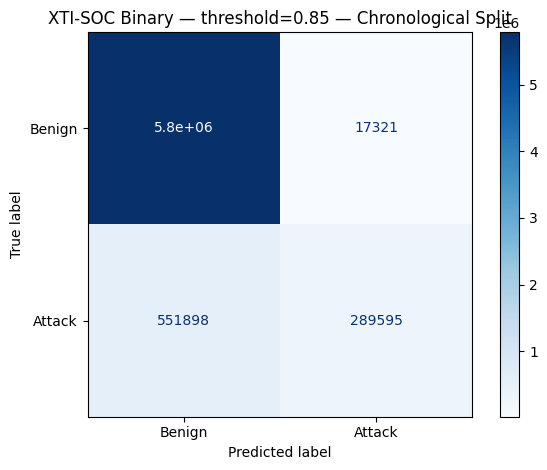

In [16]:
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, precision_recall_curve)

proba = model.predict_proba(X_test_scaled)[:, 1]
print(f'ROC-AUC: {roc_auc_score(y_test, proba):.4f}')

# Threshold sweep
print('\n=== THRESHOLD SWEEP ===')
print(f'{"Threshold":<12} {"FPR%":<10} {"FNR%":<10} {"F1":<10} {"Precision":<12} {"Recall"}')
for t in [0.50, 0.60, 0.70, 0.80, 0.85, 0.90]:
    y_t = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_t).ravel()
    fpr = fp / (fp + tn) * 100
    fnr = fn / (fn + tp) * 100
    prec = tp / (tp + fp) if (tp+fp) else 0
    rec  = tp / (tp + fn) if (tp+fn) else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    print(f'{t:<12.2f} {fpr:<10.2f} {fnr:<10.2f} {f1:<10.4f} {prec:<12.4f} {rec:.4f}')

# Final report at chosen threshold
y_pred = (proba >= BINARY_THRESHOLD).astype(int)
print(f'\n=== REPORT AT THRESHOLD {BINARY_THRESHOLD} ===')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Benign','Attack']).plot(cmap='Blues')
plt.title(f'XTI-SOC Binary — threshold={BINARY_THRESHOLD} — Chronological Split')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_PATH, 'confusion_matrix_chrono.png'), dpi=150)
plt.show()


Cell 8 — Save Remaining Artifacts

In [17]:
# Feature list
with open(os.path.join(ARTIFACT_PATH, 'feature_list.pkl'), 'wb') as f:
    pickle.dump(FEATURES, f)
print(f"feature_list.pkl saved — {len(FEATURES)} features")

# SHAP explainer
print("Building SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)
with open(os.path.join(ARTIFACT_PATH, 'explainer.pkl'), 'wb') as f:
    pickle.dump(explainer, f)
print("explainer.pkl saved")

feature_list.pkl saved — 25 features
Building SHAP TreeExplainer...
explainer.pkl saved


Cell 9 — Verify All Artifacts

In [18]:
import numpy as np

print("=== ARTIFACT VERIFICATION ===\n")
for a in ['model.pkl', 'scaler.pkl', 'explainer.pkl', 'feature_list.pkl']:
    path = os.path.join(ARTIFACT_PATH, a)
    size = os.path.getsize(path) / 1024**2
    print(f"✓ {a:25s} {size:.1f} MB")

# Reload from disk
with open(os.path.join(ARTIFACT_PATH, 'model.pkl'), 'rb') as f:
    m = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'scaler.pkl'), 'rb') as f:
    sc = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'explainer.pkl'), 'rb') as f:
    ex = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'feature_list.pkl'), 'rb') as f:
    fl = pickle.load(f)

# Smoke test predict_proba
dummy = np.zeros((1, len(fl)), dtype='float32')
dummy_scaled = sc.transform(dummy)
proba = m.predict_proba(dummy_scaled)
print(f"\nSmoke test predict_proba: {proba}")

# SHAP smoke test — XGBoost safe
sv = ex.shap_values(X_test_scaled[:50])
print(f"SHAP output type: {type(sv)}")
print(f"SHAP shape: {sv.shape if hasattr(sv, 'shape') else [s.shape for s in sv]}")

if isinstance(sv, list):
    shap_array = sv[1]
else:
    shap_array = sv

assert shap_array.shape == (50, len(fl)), f"Shape mismatch: {shap_array.shape}"
print(f"SHAP smoke test passed — shape: {shap_array.shape}")

print("\n=== PHASE 0 COMPLETE ===")
print("All 4 artifacts verified. Ready for Phase 1.")

=== ARTIFACT VERIFICATION ===

✓ model.pkl                 3.2 MB
✓ scaler.pkl                0.0 MB
✓ explainer.pkl             12.0 MB
✓ feature_list.pkl          0.0 MB

Smoke test predict_proba: [[0.913848 0.086152]]
SHAP output type: <class 'numpy.ndarray'>
SHAP shape: (50, 25)
SHAP smoke test passed — shape: (50, 25)

=== PHASE 0 COMPLETE ===
All 4 artifacts verified. Ready for Phase 1.


=====DONE FOR SOME TESTING=====

In [19]:
print("=== SCALED FEATURE STATS (sample) ===")
import pandas as pd
stats = pd.DataFrame(X_train_scaled[:10000], columns=FEATURES).describe().round(3)
print(stats.loc[['mean', 'std', 'min', 'max']].to_string())

=== SCALED FEATURE STATS (sample) ===
      Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  Fwd Pkt Len Mean  Bwd Pkt Len Max  Bwd Pkt Len Min  Bwd Pkt Len Mean  Flow Byts/s  Flow Pkts/s  Flow IAT Mean  Fwd IAT Mean  Bwd IAT Mean  Fwd PSH Flags  FIN Flag Cnt  SYN Flag Cnt  RST Flag Cnt  PSH Flag Cnt  ACK Flag Cnt  Down/Up Ratio  Fwd Seg Size Avg  Bwd Seg Size Avg
mean          0.289         3.053         3.298            5.372            1.551            0.774            0.044             0.439            0.773            0.362            -0.023        0.203        1.064          1.342         1.536         0.053          0.001           0.0         0.001           0.0        -0.016         0.004          0.526             0.439            -0.023
std           2.320         3.066         8.234          179.575            0.270            1.504            1.251             2.241            0.158           10.906             